<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/galaxy_NGC_6975.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Galaxy NGC 6975**

[NGC 6975](https://en.m.wikipedia.org/wiki/NGC_6975) also known as NGC 6976, is a spiral galaxy in the constellation Aquarius.

Let us [stretch and scale](https://docs.astropy.org/en/latest/visualization/rgb.html) the individual layers of the RGB image to better display the galaxies.

In [1]:
!pip install astropy -q

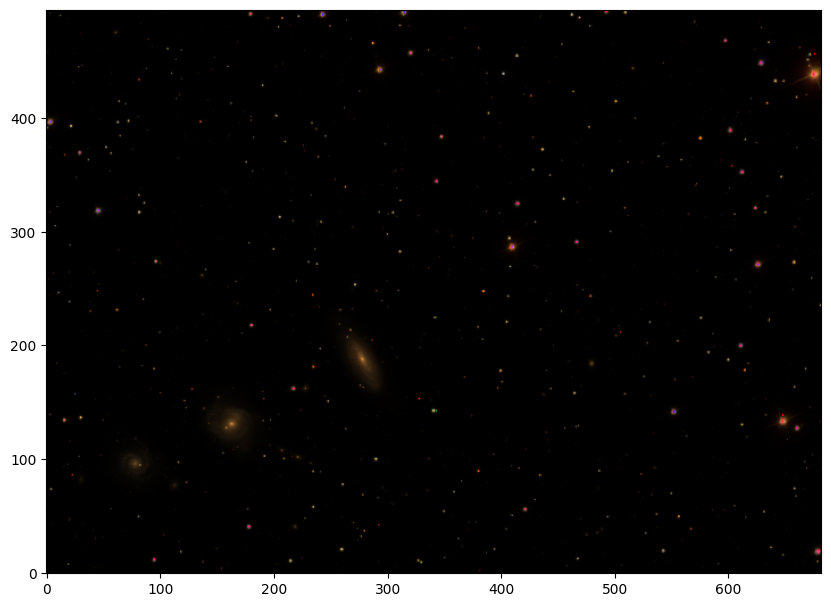

In [2]:
import matplotlib.pyplot as plt
from astropy.visualization import make_lupton_rgb
from astropy.io import fits
from astropy.utils.data import get_pkg_data_filename

# Read in the three images downloaded from here:
g_name = get_pkg_data_filename('visualization/reprojected_sdss_g.fits.bz2')
r_name = get_pkg_data_filename('visualization/reprojected_sdss_r.fits.bz2')
i_name = get_pkg_data_filename('visualization/reprojected_sdss_i.fits.bz2')
g = fits.getdata(g_name)
r = fits.getdata(r_name)
i = fits.getdata(i_name)

rgb_default = make_lupton_rgb(i, r, g, filename="ngc6976-default.jpeg")
plt.figure(figsize=(10, 8))
plt.imshow(rgb_default, origin='lower')

The image above was generated with the default parameters. However using a different scaling, e.g Q=10, stretch=0.5, faint features of the galaxies show up. Compare with Fig. 1 of Lupton et al. (2004) or the SDSS Skyserver image.


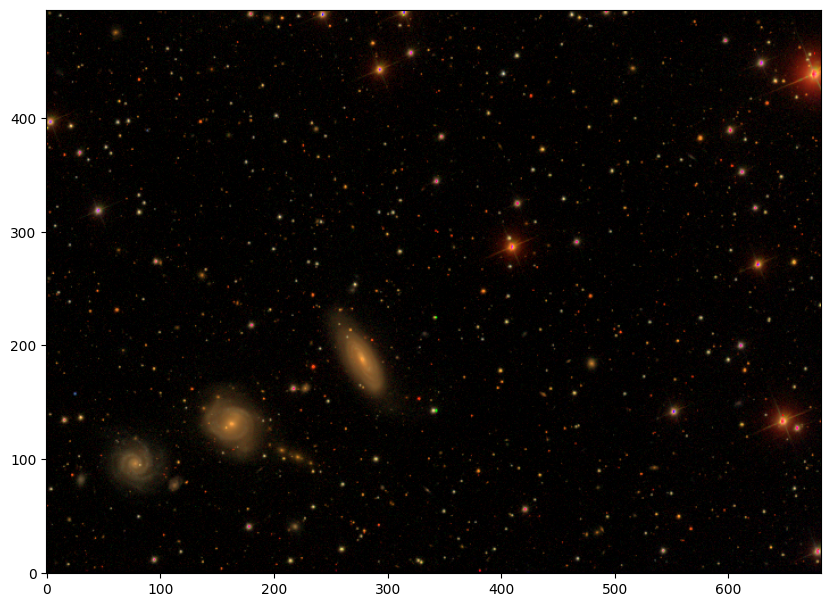

In [3]:
rgb = make_lupton_rgb(i, r, g, Q=10, stretch=0.5, filename="ngc6976.jpeg")
plt.figure(figsize=(10, 8))
plt.imshow(rgb, origin='lower')

**Cutout**

In [ ]:
from astropy.nddata import Cutout2D
from astropy import units as u

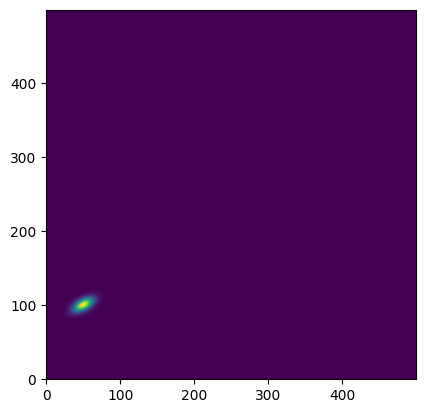

In [ ]:
import numpy as np
from astropy.modeling.models import Gaussian2D
y, x = np.mgrid[0:500, 0:500]
data = Gaussian2D(1, 50, 100, 10, 5, theta=0.5)(x, y)

import matplotlib.pyplot as plt
plt.imshow(data, origin='lower')

In [ ]:
from astropy.nddata import Cutout2D
from astropy import units as u
position = (49.7, 100.1)
size = (41, 51)     # pixels
cutout = Cutout2D(data, position, size)

The [cutout](https://docs.astropy.org/en/latest/nddata/utils.html) object can plot its bounding box on the original data using the plot_on_original() method:

<Axes: >

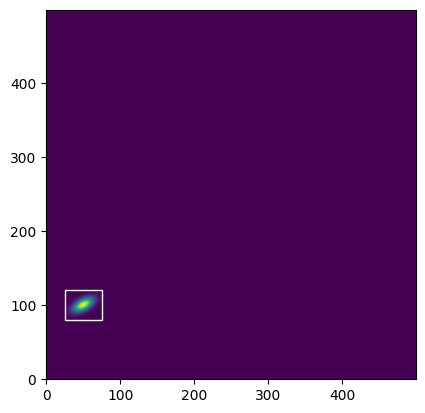

In [ ]:
plt.imshow(data, origin='lower')
cutout.plot_on_original(color='white')

Next we can create a cutout for the single object in this image. We create a cutout centered at position (x, y) = (49.7, 100.1) with a size of (ny, nx) = (41, 51) pixels:

In [ ]:
from astropy.nddata import Cutout2D
from astropy import units as u
position = (49.7, 100.1)
size = (41, 51)     # pixels
cutout = Cutout2D(data, position, size)

In [ ]:
# size keyword can also be a Quantity object:
size = u.Quantity((41, 51), u.pixel)
cutout = Cutout2D(data, position, size)

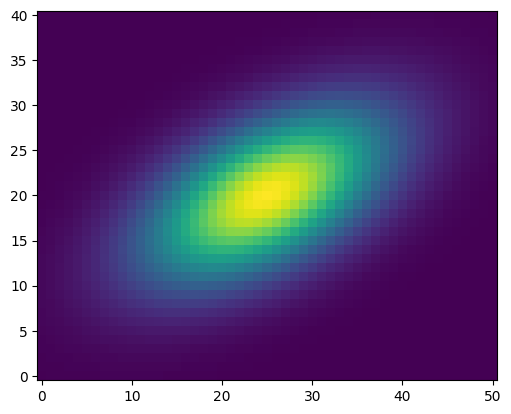

In [ ]:
cutout = Cutout2D(data, position, (41, 51))
plt.imshow(cutout.data, origin='lower')

In [ ]:
# Properties of the cutout array are also stored as attributes

# shape of the cutout array
print(cutout.shape)

# rounded pixel index of the input position
print(cutout.position_original)

# corresponding position in the cutout array
print(cutout.position_cutout)

# (non-rounded) input position in both the original and cutout arrays
print((cutout.input_position_original, cutout.input_position_cutout))

# the origin pixel in both arrays
print((cutout.origin_original, cutout.origin_cutout))

# tuple of slice objects for the original array
print(cutout.slices_original)

# tuple of slice objects for the cutout array
print(cutout.slices_cutout)

(41, 51)
(50, 100)
(25, 20)
((49.7, 100.1), (24.700000000000003, 20.099999999999994))
((25, 80), (0, 0))
(slice(80, 121, None), slice(25, 76, None))
(slice(0, 41, None), slice(0, 51, None))
